# Linear Regression

Linear regression is a statistical technique used to model the relationship between measured variables by fitting the best linear approximation to experimental data. In computational physics, it is widely applied to estimate physical parameters, quantify measurement uncertainty, and evaluate the quality of experimental models. This notebook demonstrates linear regression using a voltage–current dataset based on Ohm's law.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Experimental Data

The following example generates a synthetic voltage–current dataset with small random fluctuations to simulate experimental measurement noise.

In [2]:
V = np.linspace(0, 5, 21)
I = np.linspace(0, 200, 21) + np.random.normal(0, 1, len(V))

The scatter plot provides an initial visualization of the measured data, allowing the linear relationship between voltage and current to be inspected before fitting a regression model.

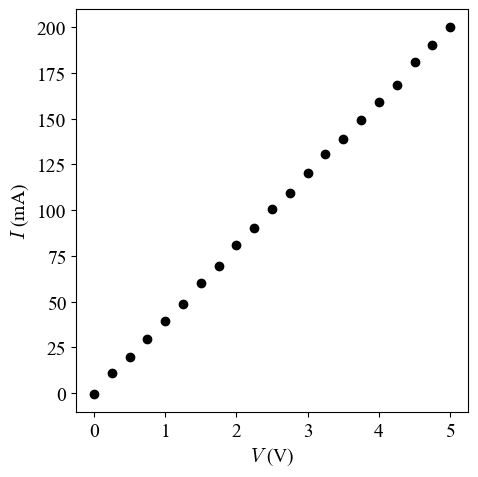

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(V, I, color="k")
plt.xlabel(r"$V$ (V)")
plt.ylabel(r"$I$ (mA)")
plt.tight_layout()
plt.show()

## Linear Regression Model

According to Ohm's law,

$$I=V/R$$

The measured data are modeled using the linear equation

$$I=mV+b$$

where $m$ is the slope and $b$ is the intercept. The resistance is estimated from

$$R=1000/m$$

where the factor of 1000 accounts for the current being expressed in milliamperes.

## Parameter Estimation

The regression parameters are estimated using the ordinary least-squares method, which minimizes the sum of squared residuals,

$$
S=\sum_{i=1}^{n}\left(I_i-\hat{I}_i\right)^2.
$$

Setting the partial derivatives of $S$ with respect to $m$ and $b$ equal to zero yields the closed-form solutions. The corresponding closed-form estimates for the slope and intercept are

$$
m=\frac{\displaystyle\sum_{i=1}^{n}(V_i-\bar V)(I_i-\bar I)}{\displaystyle\sum_{i=1}^{n}(V_i-\bar V)^2},
$$

$$
b=\bar I-m\bar V,
$$

where $\bar V$ and $\bar I$ are the sample means of the measured voltage and current, respectively. The following code estimates these parameters and additional statistical quantities using `scipy.stats.linregress`.

In [4]:
slope, intercept, r_value, p_value, std_err = stats.linregress(V, I)

In [5]:
print(f"Estimated Resistance (R): {1000/slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R²: {r_value**2:.3f}")

Estimated Resistance (R): 25.030
Intercept: -0.056
R²: 1.000


The fitted regression line is compared with the measured data to evaluate how well the linear model represents the experimental observations.

In [6]:
I_fit = slope * V + intercept

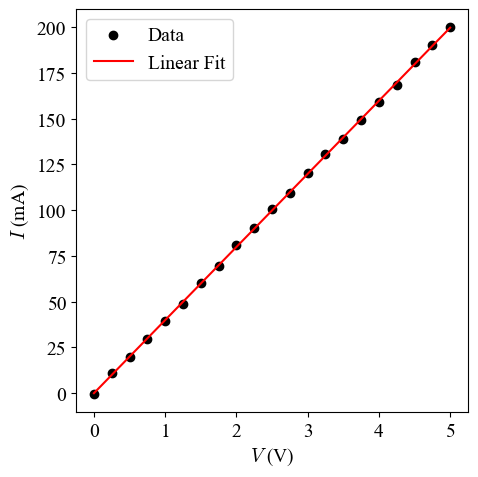

In [7]:
plt.figure(figsize=(5, 5))
plt.scatter(V, I, color="k", label="Data")
plt.plot(V, I_fit, color="r", label="Linear Fit")
plt.xlabel(r"$V$ (V)")
plt.ylabel(r"$I$ (mA)")
plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis

The residual for each observation is defined as

$$e_i=I_i-\hat{I}_i$$

where $I_i$ is the measured current and $\hat{I}_i$ is the predicted current. Residual analysis helps identify systematic deviations and assess the suitability of the linear model.

In [8]:
residuals = I - I_fit

The residual plot visualizes the distribution of prediction errors. For an appropriate linear model, the residuals should be randomly distributed around zero without noticeable trends.

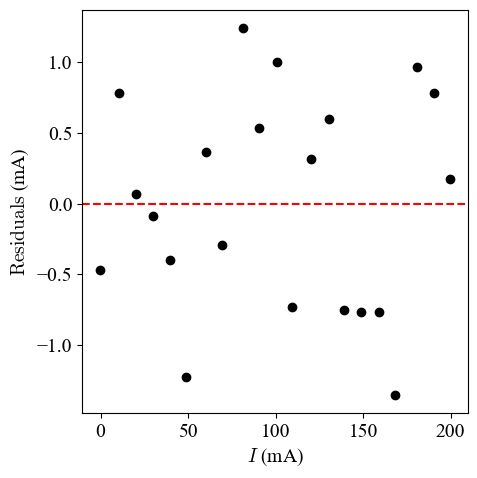

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(I, residuals, color="k")
plt.axhline(0, color="r", linestyle="--")
plt.xlabel(r"$I$ (mA)")
plt.ylabel(r"$\text{Residuals}$ (mA)")
plt.tight_layout()
plt.show()

## Model Evaluation

The quality of the regression model is evaluated using three common performance metrics.

The coefficient of determination is

$$
R^2=1-\frac{\sum_{i=1}^{n}(I_i-\hat{I}_i)^2}{\sum_{i=1}^{n}(I_i-\bar{I})^2},
$$

where the numerator is the residual sum of squares (RSS) and the denominator is the total sum of squares (TSS). Values closer to one indicate that the regression model explains a larger proportion of the variance in the measured data.

The mean absolute error (MAE) is

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}\left|I_i-\hat{I}_i\right|,
$$

which represents the average magnitude of the prediction error. Unlike RMSE, MAE assigns equal weight to all prediction errors.

The root mean squared error (RMSE) is

$$
\mathrm{RMSE}=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(I_i-\hat{I}_i)^2},
$$

which gives greater weight to larger prediction errors by squaring the residuals before averaging, making it more sensitive to large deviations than MAE.

The following code computes these performance metrics.

In [10]:
r2 = r2_score(I, I_fit)
mae = mean_absolute_error(I, I_fit)
rmse = root_mean_squared_error(I, I_fit)

In [11]:
print(f"R²: {r2:.3f}")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 1.000
MAE: 0.651
RMSE: 0.746


## Key Insights

* Linear regression estimates physical parameters by fitting the best linear relationship between experimental variables.
* Ordinary least squares determines the optimal slope and intercept by minimizing the sum of squared residuals.
* Residual analysis helps assess whether the fitted model adequately represents the observed data.
* Performance metrics such as $R^2$, $MAE$, and $RMSE$ quantify the accuracy and reliability of the fitted model.